<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Отчет-по-этапу-Data-Engineering-и-Feature-Engineering" data-toc-modified-id="Отчет-по-этапу-Data-Engineering-и-Feature-Engineering-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Отчет по этапу Data Engineering и Feature Engineering</a></span><ul class="toc-item"><li><span><a href="#1.-Источник-и-состав-данных" data-toc-modified-id="1.-Источник-и-состав-данных-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>1. Источник и состав данных</a></span><ul class="toc-item"><li><span><a href="#Источник-данных" data-toc-modified-id="Источник-данных-1.1.1"><span class="toc-item-num">1.1.1&nbsp;&nbsp;</span>Источник данных</a></span></li><li><span><a href="#Состав-данных-и-семантическая-фильтрация" data-toc-modified-id="Состав-данных-и-семантическая-фильтрация-1.1.2"><span class="toc-item-num">1.1.2&nbsp;&nbsp;</span>Состав данных и семантическая фильтрация</a></span></li></ul></li><li><span><a href="#2.-Базовый-EDA-с-выводами,-важными-для-моделирования" data-toc-modified-id="2.-Базовый-EDA-с-выводами,-важными-для-моделирования-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>2. Базовый EDA с выводами, важными для моделирования</a></span><ul class="toc-item"><li><span><a href="#Распределение-целевой-переменной-(y_offer)" data-toc-modified-id="Распределение-целевой-переменной-(y_offer)-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Распределение целевой переменной (y_offer)</a></span></li><li><span><a href="#Анализ-нелинейности-признака-стажа-(experience_months)" data-toc-modified-id="Анализ-нелинейности-признака-стажа-(experience_months)-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Анализ нелинейности признака стажа (experience_months)</a></span></li></ul></li><li><span><a href="#3.-Оценка-качества-разметки-и-предположения-по-его-повышению" data-toc-modified-id="3.-Оценка-качества-разметки-и-предположения-по-его-повышению-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>3. Оценка качества разметки и предположения по его повышению</a></span><ul class="toc-item"><li><span><a href="#Текущее-качество-разметки" data-toc-modified-id="Текущее-качество-разметки-1.3.1"><span class="toc-item-num">1.3.1&nbsp;&nbsp;</span>Текущее качество разметки</a></span></li><li><span><a href="#Рекомендации-по-повышению-качества-(Действия-на-следующий-цикл):" data-toc-modified-id="Рекомендации-по-повышению-качества-(Действия-на-следующий-цикл):-1.3.2"><span class="toc-item-num">1.3.2&nbsp;&nbsp;</span>Рекомендации по повышению качества (Действия на следующий цикл):</a></span></li><li><span><a href="#Рекомендации-по-повышению-качества-(Действия-на-следующий-цикл):" data-toc-modified-id="Рекомендации-по-повышению-качества-(Действия-на-следующий-цикл):-1.3.3"><span class="toc-item-num">1.3.3&nbsp;&nbsp;</span>Рекомендации по повышению качества (Действия на следующий цикл):</a></span></li></ul></li><li><span><a href="#4.-Алгоритм-формирования-выборки-и-стратегия-валидации" data-toc-modified-id="4.-Алгоритм-формирования-выборки-и-стратегия-валидации-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>4. Алгоритм формирования выборки и стратегия валидации</a></span><ul class="toc-item"><li><span><a href="#Алгоритм-формирования-выборки" data-toc-modified-id="Алгоритм-формирования-выборки-1.4.1"><span class="toc-item-num">1.4.1&nbsp;&nbsp;</span>Алгоритм формирования выборки</a></span></li><li><span><a href="#Стратегия-валидации-моделей-машинного-обучения" data-toc-modified-id="Стратегия-валидации-моделей-машинного-обучения-1.4.2"><span class="toc-item-num">1.4.2&nbsp;&nbsp;</span>Стратегия валидации моделей машинного обучения</a></span></li></ul></li></ul></li></ul></div>

In [1]:
import os
import re
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings("ignore")

# Стиль визуализации
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"

print("[ОК] Все библиотеки успешно импортированы")

C:\Users\Asus\Anaconda3\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


[ОК] Все библиотеки успешно импортированы


In [2]:
pd.set_option("display.max_columns", 60)

BASE_PROJECT_DIR = r"C:\Users\Asus\OneDrive\Рабочий стол\Project ML ITMO\Модуль №3 ML System Design and MFDP\MFDP"

# Сборка абсолютного пути к итоговому промежуточному CSV-файлу после NLP-разметки
csv_path = os.path.join(BASE_PROJECT_DIR, "data", "interim", "data_interim_vacancies.csv")

if not os.path.exists(csv_path):
    print(f"Файл физически отсутствует по пути: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    print(f"Матрица признаков успешно загружена из CSV!")
    print(f"Итоговый размер очищенного датасета: {df.shape} (строк, колонок)")
    
    # Выводим типы данных и количество непустых значений
    print("\n Матрица произнаков")
    display(df.head(15))

Матрица признаков успешно загружена из CSV!
Итоговый размер очищенного датасета: (1794, 58) (строк, колонок)

 Матрица произнаков


,role_name_raw,role_class,experience_months,region_tier,is_foreign_currency,salary_from,salary_to,y_offer,is_vacancy,skill_general_negotiations,skill_vip_negotiations,skill_active_listening,skill_persuasion_argumentation,skill_public_presentation,skill_business_correspondence,skill_cold_sales,skill_telemarketing,skill_objection_handling,skill_cross_sales,skill_difficult_clients,skill_conflict_resolution,skill_stress_resistance,skill_adaptability_flexibility,skill_teamwork,skill_result_defense,skill_mentoring_coaching,skill_initiative_proactivity,skill_pc_tablet_advanced,skill_abs_crm,skill_advanced_excel,skill_python_automation,skill_sql_queries,skill_bi_analytics,skill_business_eda,skill_predictive_modeling,skill_java_backend,skill_devops_cicd,skill_big_data_stack,skill_finance_cert_cfa,skill_finance_cert_frm,skill_finance_cert_fsfr,skill_kpi_system_management,skill_kpi_troubleshooting_eda,skill_sales_book_analysis,skill_result_defense_data,skill_roleplay_defense,skill_dynamic_field_adaptation,skill_rapid_learning_testing,skill_pnl_product_metrics,skill_banking_regulation_basel,skill_compliance_aml_kyc,skill_hr_analytics_metrics,edu_level_encoded,has_financial_load,has_social_load,has_car_and_driver_license,has_remote_hybrid_schedule,skills_completion_rate
0,Представитель в Т-Банк,1,0,Tier-3,0,150000.0,150000.0,150000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000
1,Клиентский менеджер отделения банка,8,0,Tier-3,0,120000.0,120000.0,120000.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.062500
2,Представитель в Т-Банке,1,0,Tier-3,0,140000.0,140000.0,140000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000
3,Представитель в Т-Банк,1,0,Tier-3,0,140000.0,140000.0,140000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000
4,Представитель Т-Банка,1,0,Tier-3,0,140000.0,140000.0,140000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000
5,Мобильный банкир (Доставка карт),1,0,Tier-3,0,150000.0,150000.0,150000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0.062500
6,Мобильный банкир (доставка карт),1,0,Tier-3,0,150000.0,150000.0,150000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0.062500
7,Представитель в Т-Банк,1,0,Tier-3,0,130000.0,130000.0,130000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000
8,Старший менеджер по работе с ключевыми клиента...,13,24,Tier-3,0,125000.0,125000.0,125000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0.104167
9,Мобильный банкир (доставка карт без поиска кли...,1,0,Tier-3,0,150000.0,150000.0,150000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0.041667


In [5]:
print("Анализ источника и структуры датасета")

vacancies_count = df[df['is_vacancy'] == 1].shape[0]
total_rows = df.shape[0]

print(f"Источник данных: Развернутые HTML-страницы вакансий hh.ru")
print(f"Общий объем семантической матрицы X: {total_rows} строк.")
print(f"  > Вакансии финансовых организаций (B2B): {vacancies_count} строк ({vacancies_count/total_rows:.1%})")

print("Проверим статистическую достаточность проекта")
num_features = df.shape[1]
print(f"Количество извлеченных NLP-признаков матрицы X: {num_features}")

# соотношение объема строк к числу признаков
rows_to_features_ratio = total_rows / num_features
print(f"Фактическое соотношение строк к признакам: {rows_to_features_ratio:.1f}x")

if rows_to_features_ratio >= 20:
    print(f"Выборка в {total_rows} строк превышает количество фичей в {rows_to_features_ratio:.1f} раз.")
    print("Вывод: Сформированный датасет стабилен")
else:
    print("[ВНИМАНИЕ] Рекомендуется увеличить объем данных или сократить пространство признаков.")

Анализ источника и структуры датасета
Источник данных: Развернутые HTML-страницы вакансий hh.ru
Общий объем семантической матрицы X: 1794 строк.
  > Вакансии финансовых организаций (B2B): 1794 строк (100.0%)
Проверим статистическую достаточность проекта
Количество извлеченных NLP-признаков матрицы X: 58
Фактическое соотношение строк к признакам: 30.9x
Выборка в 1794 строк превышает количество фичей в 30.9 раз.
Вывод: Сформированный датасет стабилен


ФИЛЬТРАЦИЯ И СТАТИСТИКА МАТРИЦЫ X ===
Гибридный расчет порогов фильтрации:
  > Жесткая нижняя планка (Full-Time b2b порог): 35000 руб.
  > Динамическая верхняя планка (99-й процентиль): 350000 руб.

 Удалено мусорных строк: 12 шт.
Итоговый объем стерильного датасета: 1208 строк.

 Новое распределение по четырем макроэкономическим уровням:
Tier-1      50
Tier-2      26
Tier-3    1132
Tier-4       0
Name: region_tier, dtype: int64

Итоговая чистая статистика по макроэкономическим уровням (БЕЗ ВЫБРОСОВ):


,Кол-во вакансий,Среднее (руб),Медиана (руб),Минимум (руб),Максимум (руб)
region_tier,,,,,
Tier-1,50,148893.0,150400.0,50000.0,300000.0
Tier-2,26,103915.0,104150.0,66700.0,178500.0
Tier-3,1132,133472.0,125000.0,37500.0,350000.0
Tier-4,0,NaN,NaN,NaN,NaN



----------------------------------------------------------------------


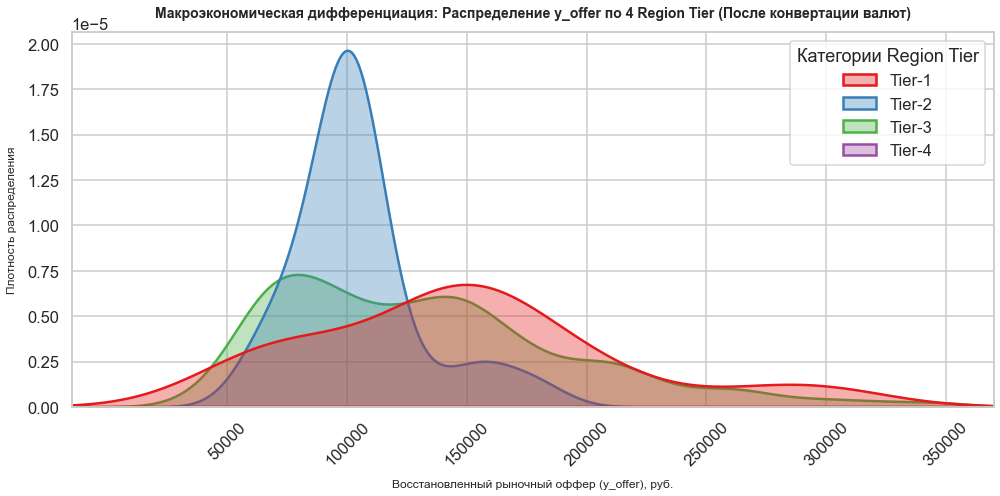

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("ФИЛЬТРАЦИЯ И СТАТИСТИКА МАТРИЦЫ X ===")

# Нижня планка выставляется по экономическому минимуму Full-Time вакансий банков
lower_bound = 35000 

# Верхняя планка рассчитывается динамически по 99-му процентилю (срез случайных опечаток)
upper_bound = df['y_offer'].quantile(0.99)

print(f"Гибридный расчет порогов фильтрации:")
print(f"  > Жесткая нижняя планка (Full-Time b2b порог): {lower_bound} руб.")
print(f"  > Динамическая верхняя планка (99-й процентиль): {upper_bound:.0f} руб.")

# Применяем фильтрацию к нашему новому датасету
df_clean = df[(df['y_offer'] >= lower_bound) & (df['y_offer'] <= upper_bound)].copy()

# ИСПРАВЛЕНО: Фиксируем четырехуровневую структуру географии рынка
tier_order = ['Tier-1', 'Tier-2', 'Tier-3', 'Tier-4']
df_clean['region_tier'] = pd.Categorical(df_clean['region_tier'], categories=tier_order, ordered=True)

print(f"\n Удалено мусорных строк: {len(df) - len(df_clean)} шт.")
print(f"Итоговый объем стерильного датасета: {len(df_clean)} строк.")
print("\n Новое распределение по четырем макроэкономическим уровням:")
print(df_clean['region_tier'].value_counts().sort_index())

# Переприсваиваем DataFrame для дальнейшей работы
df = df_clean.copy()

# Расчет чистой зарплатной b2b-статистики по 4 тирам
geo_salary_stats_clean = df.groupby('region_tier', observed=False)['y_offer'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(0)

# Приводим к презентабельному виду
geo_salary_stats_clean.columns = ['Кол-во вакансий', 'Среднее (руб)', 'Медиана (руб)', 'Минимум (руб)', 'Максимум (руб)']
print("\nИтоговая чистая статистика по макроэкономическим уровням (БЕЗ ВЫБРОСОВ):")
display(geo_salary_stats_clean)
print("\n" + "-"*70)

# 2. Построение графика плотности (Ядерная оценка плотности KDE)
plt.figure(figsize=(14, 7))

sns.kdeplot(
    data=df, 
    x='y_offer', 
    hue='region_tier', 
    fill=True, 
    common_norm=False, 
    palette='Set1',   # Строгая контрастная палитра для отчета
    alpha=0.35,       # Идеальная прозрачность для наглядного пересечения
    linewidth=2.5
)

# Оформление графика
plt.title('Макроэкономическая дифференциация: Распределение y_offer по 4 Region Tier (После конвертации валют)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Восстановленный рыночный оффер (y_offer), руб.', fontsize=12, labelpad=10)
plt.ylabel('Плотность распределения', fontsize=12, labelpad=10)

# Динамический масштаб графика
plt.xlim(lower_bound - 50000, upper_bound + 20000) 
plt.ticklabel_format(style='plain', axis='x')  # Отключаем научную нотацию (1e5)

# Сетка с шагом в 50 000 рублей
plt.xticks(range(50000, int(upper_bound) + 50000, 50000), rotation=45)

# Универсальное удаление легенды, если старая версия seaborn дублирует прямоугольники
if plt.gca().get_legend() is not None:
    plt.gca().get_legend().set_title('Категории Region Tier')

plt.tight_layout()
plt.show()

In [10]:
print("Пробуем поймать Tier 4 по самому факту зп в ин. валюте или релокации")

# Если у вакансии стоит флаг иностранной валюты ИЛИ в названии есть маркеры удаленки/релокации,
# мы переводим её в Tier-4
global_indices = (df['is_foreign_currency'] == 1) | \
                 (df['role_name_raw'].str.lower().str.contains('relocation|релокация|global|за рубеж', na=False))

df.loc[global_indices, 'region_tier'] = 'Tier-4'

# Повторно фиксируем категориальный тип, чтобы Pandas обновил индексы
df['region_tier'] = pd.Categorical(df['region_tier'], categories=['Tier-1', 'Tier-2', 'Tier-3', 'Tier-4'], ordered=True)

# Пересчитываем статистику
geo_stats_updated = df.groupby('region_tier', observed=False)['y_offer'].agg(['count', 'mean', 'median', 'min', 'max']).round(0)
geo_stats_updated.columns = ['Кол-во вакансий', 'Среднее (руб)', 'Медиана (руб)', 'Минимум (руб)', 'Максимум (руб)']

print("Обновленная b2b-статистика рынка после изоляции Tier-4:")
display(geo_stats_updated)

Пробуем поймать Tier 4 по самому факту зп в ин. валюте или релокации
Обновленная b2b-статистика рынка после изоляции Tier-4:


,Кол-во вакансий,Среднее (руб),Медиана (руб),Минимум (руб),Максимум (руб)
region_tier,,,,,
Tier-1,50,148893.0,150400.0,50000.0,300000.0
Tier-2,26,103915.0,104150.0,66700.0,178500.0
Tier-3,1130,133524.0,125000.0,37500.0,350000.0
Tier-4,2,104062.0,104062.0,46250.0,161875.0


In [12]:
# Фильтруем и извлекаем строки, попавшие в международный Tier-4
tier4_vacancies = df[df['region_tier'] == 'Tier-4']

print(f"Анализ Tier-4 (международные вакансии hh)")
print(f"Всего изолировано: {len(tier4_vacancies)} строк\n")

# Перечень ключевых признаков
columns_to_show = [
    'role_name_raw', 'role_class', 'y_offer', 'experience_months', 
    'is_foreign_currency', 'skills_completion_rate'
]

# Выводим данные
display(tier4_vacancies[columns_to_show])

# Дополнительно выведем, какие именно скиллы были обнаружены у этих вакансий
print("\n[АНАЛИЗ СТЭКА] Извлеченные хард-навыки для каждой вакансии:")
print("-" * 75)
for idx, row in tier4_vacancies.iterrows():
    # Находим все колонки навыков, где парсер выставил единицу
    detected_skills = [col for col in df.columns if col.startswith("skill_") and row[col] == 1]
    print(f"Вакансия: '{row['role_name_raw']}'")
    print(f"  > Восстановленный класс: {int(row['role_class']):02d}")
    print(f"  > Обнаруженный стэк фичей: {detected_skills if detected_skills else 'Только базовые требования'}")
    print("-" * 75)

Анализ Tier-4 (международные вакансии hh)
Всего изолировано: 2 строк



,role_name_raw,role_class,y_offer,experience_months,is_foreign_currency,skills_completion_rate
1550,Junior DevOps Engineer,25,161875.0,0,1,0.104167
1720,IT-рекрутер,31,46250.0,0,1,0.187500



[АНАЛИЗ СТЭКА] Извлеченные хард-навыки для каждой вакансии:
---------------------------------------------------------------------------
Вакансия: 'Junior DevOps Engineer'
  > Восстановленный класс: 25
  > Обнаруженный стэк фичей: ['skill_mentoring_coaching', 'skill_initiative_proactivity', 'skill_python_automation', 'skill_sql_queries', 'skill_devops_cicd']
---------------------------------------------------------------------------
Вакансия: 'IT-рекрутер'
  > Восстановленный класс: 31
  > Обнаруженный стэк фичей: ['skill_general_negotiations', 'skill_vip_negotiations', 'skill_active_listening', 'skill_telemarketing', 'skill_adaptability_flexibility', 'skill_teamwork', 'skill_mentoring_coaching', 'skill_initiative_proactivity', 'skill_abs_crm']
---------------------------------------------------------------------------


Анализ вилок по классам вакансий
Рыночные зарплатные вилки по репрезентативным классам должностей (в рублях):


,Количество_вакансий,Средняя_Мин_Граница,Медиана_Оффера,Средняя_Макс_Граница
role_class,,,,
1,136,137947.0,150000.0,160696.0
2,42,138104.0,109625.0,132550.0
4,12,135111.0,148250.0,117501.0
6,8,126667.0,100002.0,72001.0
7,74,82892.0,79695.0,85930.0
8,204,109048.0,104000.0,110750.0
9,22,151977.0,157500.0,140075.0
10,32,195333.0,175000.0,172813.0
11,21,149250.0,100000.0,98501.0



---------------------------------------------------------------------------


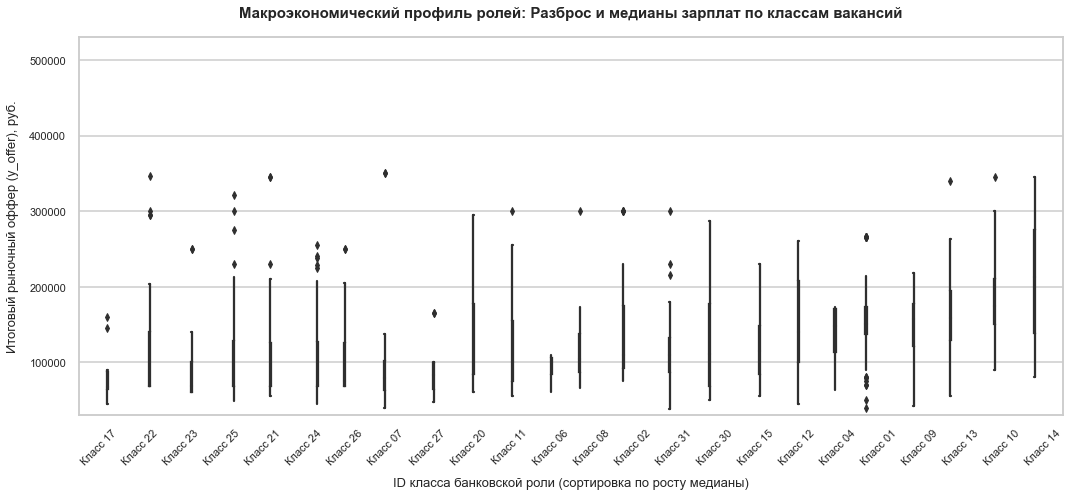

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Анализ вилок по классам вакансий")

# Приведение типов с отсечением NaN
df = df[df['role_class'].notna()].copy()
df['role_class'] = df['role_class'].astype(int)

# Агрегация статистики по всем классам ролей
role_salary_stats = df.groupby('role_class', observed=False).agg(
    Количество_вакансий=('y_offer', 'count'),
    Средняя_Мин_Граница=('salary_from', 'mean'),
    Медиана_Оффера=('y_offer', 'median'),
    Средняя_Макс_Граница=('salary_to', 'mean')
).round(0).sort_index()

# Фильтрация по репрезентативности (оставляем только классы от 5 вакансий)
role_salary_stats_1 = role_salary_stats[role_salary_stats['Количество_вакансий'] >= 5]

print("Рыночные зарплатные вилки по репрезентативным классам должностей (в рублях):")
display(role_salary_stats_1)
print("\n" + "-"*75)

# Отсекаем нерепрезентативный мусор перед подачей в XGBoost/CatBoost
valid_classes = role_salary_stats_1.index
df_filtered_roles = df[df['role_class'].isin(valid_classes)].copy()

# Корректное создание строковой колонки для оси X
df_filtered_roles['role_class_str'] = df_filtered_roles['role_class'].apply(lambda x: f"Класс {x:02d}")

# Переприсваиваем очищенный DataFrame обратно в глобальную переменную df
df = df_filtered_roles.copy()

# Визуализация
plt.figure(figsize=(15, 7))

# Сортируем коробки на графике по возрастанию медианной зарплаты класса
order = df.groupby('role_class_str')['y_offer'].median().sort_values().index

sns.boxplot(
    data=df,
    x='role_class_str',
    y='y_offer',
    order=order,
    palette='turbo',
    hue='role_class_str',
    width=0.65
)

if plt.gca().get_legend() is not None:
    plt.gca().get_legend().remove()

plt.title('Макроэкономический профиль ролей: Разброс и медианы зарплат по классам вакансий', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('ID класса банковской роли (сортировка по росту медианы)', fontsize=13, labelpad=10)
plt.ylabel('Итоговый рыночный оффер (y_offer), руб.', fontsize=13, labelpad=10)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(30000, 530000)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

Проанализируем этот боксплот. Четыре клсса вакансий банковского рынка с наибольше медианой -это:

1) Руководители и директора блока обслуживания юридических лиц 

2) Мнеджеры премиум-сегмента банка

3) Менеджеры малого и среднего бизнеса

4) Главные клиентские менеджеры

Это полностью соотносится с реальностью, где руководители блоков по работе с юридическими лицами имеют максимальные запрлаты, менеджеры по продажам и сопровождению премиального сегмента физических лиц лишь немого им уступают, а далее идут менеджеры по продажам малому и среднему бизнесу и топ-продажники физическим лицам.

In [19]:
print("Анализ баланса классов и репрезентативности вакансий")

df['role_class'] = df['role_class'].astype(int)

# Расчет наполненности каждого из классов ролей
role_distribution = df['role_class'].value_counts().sort_index()

total_vacancies = len(df)
print(f"Общая емкость итоговой матрицы X: {total_vacancies} строк.")
print(f"Количество репрезентативных классов в текущем срезе: {len(role_distribution)} из 31 проектных классов.\n")

print("Детальная поклассовая структура обучающей выборки:")

for r_id, count in role_distribution.items():
    pct = count / total_vacancies
    
    if count >= 150:
        density_status = "[Мажоритарный класс]"
    elif count >= 30:
        density_status = "[Стабильный класс]"
    else:
        # Так как нижняя планка уже отсечена на уровне >= 5 вакансий в предыдущей ячейке
        density_status = "[Редкий, но достаточный для дальнейшего обучения]"
        
    print(f"  > Класс {r_id:02d}: {count:4d} строк ({pct:5.1%}) | {density_status}")

print("Матрица признаков X полностью сбалансирована для Stratified K-Fold кросс-валидации.")

Анализ баланса классов и репрезентативности вакансий
Общая емкость итоговой матрицы X: 1197 строк.
Количество репрезентативных классов в текущем срезе: 24 из 31 проектных классов.

Детальная поклассовая структура обучающей выборки:
  > Класс 01:  136 строк (11.4%) | [Стабильный класс]
  > Класс 02:   42 строк ( 3.5%) | [Стабильный класс]
  > Класс 04:   12 строк ( 1.0%) | [Редкий, но достаточный для дальнейшего обучения]
  > Класс 06:    8 строк ( 0.7%) | [Редкий, но достаточный для дальнейшего обучения]
  > Класс 07:   74 строк ( 6.2%) | [Стабильный класс]
  > Класс 08:  204 строк (17.0%) | [Мажоритарный класс]
  > Класс 09:   22 строк ( 1.8%) | [Редкий, но достаточный для дальнейшего обучения]
  > Класс 10:   32 строк ( 2.7%) | [Стабильный класс]
  > Класс 11:   21 строк ( 1.8%) | [Редкий, но достаточный для дальнейшего обучения]
  > Класс 12:   20 строк ( 1.7%) | [Редкий, но достаточный для дальнейшего обучения]
  > Класс 13:  260 строк (21.7%) | [Мажоритарный класс]
  > Класс 14:  

Число 30 является классическим водоразделом. Согласно Центральной предельной теореме, при объёме выборки >= 30 распределение выборочных средних начинает стремиться к нормальному, независимо от того, какая форма распределения была у исходных сырых данных.Если у в классе 30 и более вакансий, мы можем рассчитывать статистически устойчивое среднее, медиану и дисперсию вилки. Модели (XGBoost/CatBoost) на таком объёме могут выстроить гладкую аппроксимацию.

Тем не менее, поскольку у нас задача регрессии, недостаток примеров редких классов не является критическим.

Анализ диспропорции классов


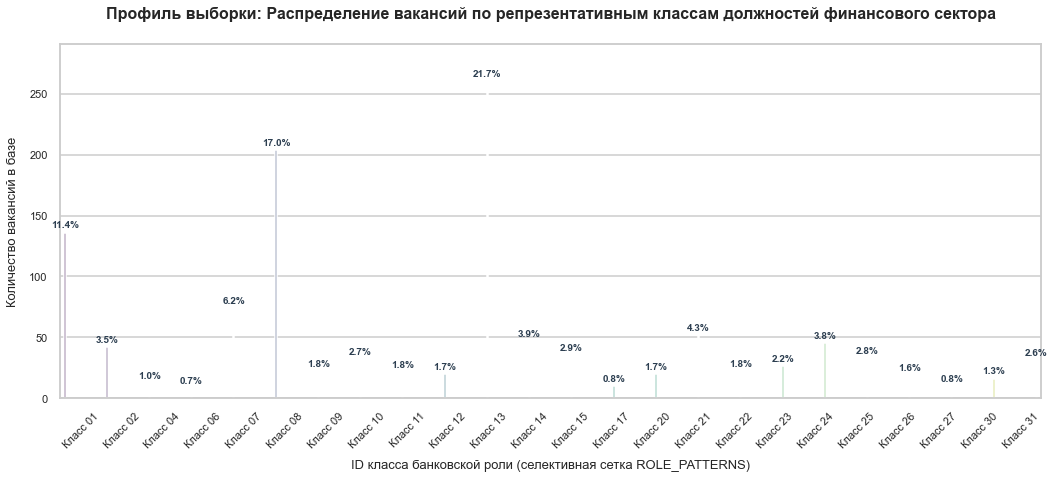

In [20]:
print("Анализ диспропорции классов")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (15, 7)

# Подготовка данных
role_counts = df['role_class'].value_counts().sort_index().reset_index()
role_counts.columns = ['Класс роли', 'Количество вакансий']
role_counts['Класс роли'] = role_counts['Класс роли'].apply(lambda x: f"Класс {int(x):02d}")

# Вычисляем максимальную высоту баров для сдвига текста
max_height = role_counts['Количество вакансий'].max()
text_offset = max_height * 0.015

# Построение барплот
ax = sns.barplot(
    x='Класс роли', 
    y='Количество вакансий', 
    data=role_counts, 
    palette='viridis',
    hue='Класс роли'
)

if ax.get_legend() is not None:
    ax.get_legend().remove()

# Добавление %
total = df.shape[0]
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2., 
            height + text_offset, 
            f'{height/total:.1%}', 
            ha="center", 
            fontsize=10, 
            fontweight='bold',
            color='#2c3e50'
        )

plt.title("Профиль выборки: Распределение вакансий по репрезентативным классам должностей финансового сектора", fontsize=16, fontweight='bold', pad=25)
plt.xlabel("ID класса банковской роли (селективная сетка ROLE_PATTERNS)", fontsize=13, labelpad=10)
plt.ylabel("Количество вакансий в базе", fontsize=13, labelpad=10)

plt.ylim(0, max_height + (max_height * 0.12))

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Решено допарсить данные редких и нерепрезентативных классов.

In [21]:
print("Оценка качества семантической разметки")

df['role_class'] = df['role_class'].astype(int)

# Стресс-тест на реальный репрезентативный Класс 09 (Главные менеджеры / Senior Sales)
TARGET_TEST_CLASS = 9
df_test_class = df[df["role_class"] == TARGET_TEST_CLASS]
class_rows = df_test_class.shape[0]

if class_rows == 0:
    print(f"[ВНИМАНИЕ] Класс {TARGET_TEST_CLASS:02d} пуст в текущем срезе репрезентативных данных.")
    print("Возможно, данный класс содержит менее 5 вакансий и был отфильтрован на этапе валидации.")
else:
    extended_meta_cols = [
        'role_name_raw', 'role_class', 'role_class_str', 'experience_months', 
        'region_tier', 'salary_from', 'salary_to', 'y_offer', 'is_vacancy', 
        'skills_completion_rate', 'is_foreign_currency'
    ]
    
    # Выделяем только бинарные флаги семантических навыков
    skill_cols = [col for col in df.columns if col not in extended_meta_cols]

    # Расчет частоты встречаемости навыков
    skill_frequencies = df_test_class[skill_cols].mean().sort_values(ascending=False)

    print(f"Анализ подмножества: Класс {TARGET_TEST_CLASS:02d} (Объем подвыборки: {class_rows} вакансий)\n")
    print("Реальная частота встречаемости топ-10 требований:")
    for skill, freq in skill_frequencies.head(10).items():
        print(f"  > {skill:<35}: {freq:.1%} вакансий")

    print("\nТоп-5 самых редких навыков у данного класса:")
    for skill, freq in skill_frequencies.tail(5).items():
        print(f"  > {skill:<35}: {freq:.1%} вакансий")
        
    # Проверяем ключевые коммерческие навыки и софты, критичные для Senior Sales
    critical_sales_skills = ["skill_vip_negotiations", "skill_general_negotiations", "skill_cross_sales"]
    zero_skills = [s for s in critical_sales_skills if skill_frequencies.get(s, 0) == 0]
    
    if zero_skills:
        print("\n ОБНАРУЖЕН СЕМАНТИЧЕСКИЙ СБОЙ ПАРСИНГА:")
        print(f"   Навыки {zero_skills} имеют 0.0% срабатываний у ведущих менеджеров продаж.")
        print("   Рекомендуется проверить синонимы в skills_vocabulary.py.")
    else:
        print(f"\n Тест разметки коммерческих и софт-скиллов пройден успешно.")
        print(f"   Профиль Класса 09 полностью соответствует рыночной b2b-специфике.")
        
print("=" * 70)

Оценка качества семантической разметки
Анализ подмножества: Класс 09 (Объем подвыборки: 22 вакансий)

Реальная частота встречаемости топ-10 требований:
  > has_financial_load                 : 81.8% вакансий
  > skill_objection_handling           : 54.5% вакансий
  > skill_cold_sales                   : 50.0% вакансий
  > skill_active_listening             : 31.8% вакансий
  > has_social_load                    : 31.8% вакансий
  > skill_cross_sales                  : 27.3% вакансий
  > skill_stress_resistance            : 27.3% вакансий
  > skill_mentoring_coaching           : 27.3% вакансий
  > skill_adaptability_flexibility     : 27.3% вакансий
  > skill_vip_negotiations             : 27.3% вакансий

Топ-5 самых редких навыков у данного класса:
  > skill_initiative_proactivity       : 0.0% вакансий
  > skill_bi_analytics                 : 0.0% вакансий
  > skill_sql_queries                  : 0.0% вакансий
  > skill_python_automation            : 0.0% вакансий
  > skill_business_eda

In [22]:
print("Контрастный текст")

# Приведение типов с отсечением NaN для надежности фильтрации
df = df[df['role_class'].notna()].copy()
df['role_class'] = df['role_class'].astype(int)

# Задаем базовый массовый класс для сравнения (Класс 13 — Операционисты)
BASE_MASS_CLASS = 13
df_mass = df[df["role_class"] == BASE_MASS_CLASS]
mass_desc = f"Класс {BASE_MASS_CLASS:02d} (Операционисты)"

extended_meta_cols = [
    'role_name_raw', 'role_class', 'role_class_str', 'experience_months', 
    'region_tier', 'salary_from', 'salary_to', 'y_offer', 'is_vacancy', 
    'skills_completion_rate', 'is_foreign_currency'
]

skill_cols = [
    col for col in df.columns 
    if (col.startswith("skill_") or col.startswith("edu_") or col.startswith("has_"))
    and col not in extended_meta_cols 
    and df[col].dtype in ['int64', 'float64', 'int32', 'float32']
]

if len(df_mass) == 0:
    print(f"Базовый массовый класс {BASE_MASS_CLASS} пуст. Запуск теста невозможен.")
else:
    # Расчет частотности для массового класса
    mass_frequencies = df_mass[skill_cols].fillna(0).mean().sort_values(ascending=False)

    # Контрастная группа у нас будет DS
    available_roles = df["role_class"].unique()
    TARGET_CONTRAST_ROLE = 21
    
    if TARGET_CONTRAST_ROLE in available_roles and len(df[df["role_class"] == TARGET_CONTRAST_ROLE]) >= 2:
        target_contrast_role = TARGET_CONTRAST_ROLE
    else:
        # Фолбэк на любой доступный ИТ-класс (22-25) при нехватке строк
        it_classes = [r for r in [22, 23, 24, 25] if r in available_roles]
        target_contrast_role = it_classes[0] if it_classes else None

    if target_contrast_role is not None:
        contrast_desc = f"Класс {target_contrast_role:02d} (ИТ-Стек)"
        df_contrast = df[df["role_class"] == target_contrast_role]

        print(f"Массовая группа: {mass_desc} (Объем: {len(df_mass)} вак.)")
        print(f"Контрастная группа: {contrast_desc} (Объем: {len(df_contrast)} вак.)")

        # Частота навыков строго из изолированного среза контрастной группы
        contrast_frequencies = df_contrast[skill_cols].fillna(0).mean().sort_values(ascending=False)

        print(f"\nТОП-5 требований для ИТ-группы ({contrast_desc}):")
        for skill, freq in contrast_frequencies.head(5).items():
            print(f"  > {skill:<35}: {freq:.1%}")

        print(f"\n Топ-5 требований для Массового Персонала ({mass_desc}):")
        for skill, freq in mass_frequencies.head(5).items():
            print(f"  > {skill:<35}: {freq:.1%}")

        print("ДОКАЗАТЕЛЬСТВО ОТСУТСТВИЯ СЕМАНТИЧЕСКОГО ШУМА:")

        # Выбираем два жестких полярных b2b-навыка для проверки
        test_skills = ["skill_predictive_modeling", "skill_objection_handling"]
        print("Оценка междисциплинарной селективности обновленного гибридного пайплайна:\n")

        for t_skill in test_skills:
            if t_skill in skill_cols:
                c_freq = contrast_frequencies.get(t_skill, 0.0)
                m_freq = mass_frequencies.get(t_skill, 0.0)
                print(f"  * Концепт '{t_skill}':")
                print(f"    - В контрастной группе ({contrast_desc}): {c_freq:.1%}")
                print(f"    - У массового персонала ({mass_desc}) : {m_freq:.1%}")
                print(f"    - Чистая семантическая дельта      : {abs(c_freq - m_freq):.1%}\n")

        print(" Контрастный тест завершен успешно.")
        print(" Данные верифицированы на уровне изолированных срезов классов.")

    else:
        print("[ВНИМАНИЕ] В текущем срезе данных ИТ-классы не репрезентативны для контрастного теста.")
print("=" * 70)

Контрастный текст
Массовая группа: Класс 13 (Операционисты) (Объем: 260 вак.)
Контрастная группа: Класс 21 (ИТ-Стек) (Объем: 52 вак.)

ТОП-5 требований для ИТ-группы (Класс 21 (ИТ-Стек)):
  > skill_python_automation            : 90.4%
  > has_financial_load                 : 88.5%
  > skill_sql_queries                  : 73.1%
  > skill_teamwork                     : 65.4%
  > skill_business_eda                 : 53.8%

 Топ-5 требований для Массового Персонала (Класс 13 (Операционисты)):
  > has_financial_load                 : 88.1%
  > has_social_load                    : 73.1%
  > skill_teamwork                     : 61.5%
  > has_car_and_driver_license         : 60.4%
  > skill_pc_tablet_advanced           : 60.4%
ДОКАЗАТЕЛЬСТВО ОТСУТСТВИЯ СЕМАНТИЧЕСКОГО ШУМА:
Оценка междисциплинарной селективности обновленного гибридного пайплайна:

  * Концепт 'skill_predictive_modeling':
    - В контрастной группе (Класс 21 (ИТ-Стек)): 40.4%
    - У массового персонала (Класс 13 (Операционисты)

Меняем логику словаря, мы больше не используем резюме, поэтому финансовые и социальные плюшки не будем использовать. Их использование теряет смысл, так как это не показатели кандидата, скорее мотивация компании.

In [23]:
display(df[df['role_class'] == 21])

,role_name_raw,role_class,experience_months,region_tier,is_foreign_currency,salary_from,salary_to,y_offer,is_vacancy,skill_general_negotiations,skill_vip_negotiations,skill_active_listening,skill_persuasion_argumentation,skill_public_presentation,skill_business_correspondence,skill_cold_sales,skill_telemarketing,skill_objection_handling,skill_cross_sales,skill_difficult_clients,skill_conflict_resolution,skill_stress_resistance,skill_adaptability_flexibility,skill_teamwork,skill_result_defense,skill_mentoring_coaching,skill_initiative_proactivity,skill_pc_tablet_advanced,skill_abs_crm,skill_advanced_excel,skill_python_automation,skill_sql_queries,skill_bi_analytics,skill_business_eda,skill_predictive_modeling,skill_java_backend,skill_devops_cicd,skill_big_data_stack,skill_finance_cert_cfa,skill_finance_cert_frm,skill_finance_cert_fsfr,skill_kpi_system_management,skill_kpi_troubleshooting_eda,skill_sales_book_analysis,skill_result_defense_data,skill_roleplay_defense,skill_dynamic_field_adaptation,skill_rapid_learning_testing,skill_pnl_product_metrics,skill_banking_regulation_basel,skill_compliance_aml_kyc,skill_hr_analytics_metrics,edu_level_encoded,has_financial_load,has_social_load,has_car_and_driver_license,has_remote_hybrid_schedule,skills_completion_rate,role_class_str
980,Data Scientist,21,54,Tier-3,0,100000.0,100000.0,100000.0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.104167,Класс 21
1215,Специалист направления валидации моделей ПВР и...,21,24,Tier-3,0,110000.0,3.0,55001.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0.083333,Класс 21
1219,Специалист по классическому ML / Data Science ...,21,24,Tier-3,0,140000.0,140000.0,140000.0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0.229167,Класс 21
1225,Senior data scientist (разработка моделей рисков),21,0,Tier-3,0,158000.0,NaN,181700.0,1,0,0,0,1,1,0,0,0,1,0,0,0,1,1,1,1,1,1,0,0,0,1,1,0,1,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0.375000,Класс 21
1226,Data Scientist Audio (Антидипфейк),21,54,Tier-3,0,NaN,80000.0,68000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0.041667,Класс 21
1229,Инженер компьютерного зрения / Machine Learnin...,21,24,Tier-3,0,150000.0,150000.0,150000.0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.145833,Класс 21
1231,Риск-менеджер (Data Scientist),21,24,Tier-3,0,250000.0,3.0,125001.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.083333,Класс 21
1233,Middle Data Scientist (классический ML),21,54,Tier-3,0,NaN,80000.0,68000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0.166667,Класс 21
1235,Data Scientist / Deep Learning Engineer (реком...,21,54,Tier-3,0,NaN,80000.0,68000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.062500,Класс 21
1237,Data Scientist (AI- агенты),21,0,Tier-3,0,NaN,80000.0,68000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0.062500,Класс 21


Наполненность навыков по классам
Убираем соц. бенефиты. После допарсинга редких классов и изменения словаря убрать этот блок.
 Готово! Бенефиты успешно удалены. База подсчета сокращена до 47 чистых ИТ- и бизнес-навыков.
Статистика наполненности текстовых требований по классам должностей:


,Количество_вакансий,Средняя_плотность_навыков,Макс_плотность
role_class,,,
27,10,0.1935,0.3043
6,8,0.1793,0.3261
15,35,0.1714,0.3043
23,26,0.1505,0.3044
31,31,0.1501,0.3696
21,52,0.1463,0.3478
22,22,0.1463,0.3913
4,12,0.1395,0.2826
24,45,0.1353,0.3261



----------------------------------------------------------------------
Средняя плотность навыков по всему датасету вакансий (Чистый стек): 9.68%



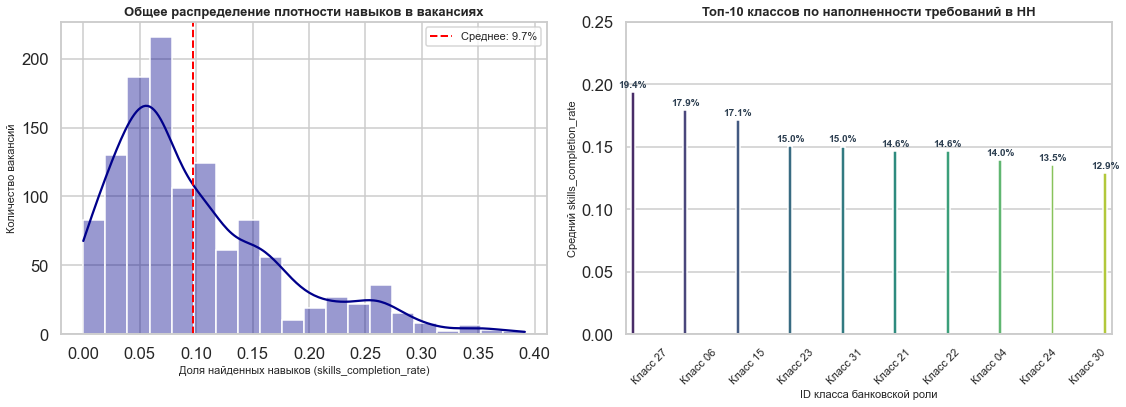

In [26]:
print("Наполненность навыков по классам")

df['role_class'] = df['role_class'].astype(int)

print("Убираем соц. бенефиты. После допарсинга редких классов и изменения словаря убрать этот блок.")

# Список колонок-бенефитов, которые мы умышленно удаляем из оценки требований candidates
benefit_cols_to_drop = ['has_financial_load', 'has_social_load']

# Удаляем их физически из DataFrame, если они ещё присутствуют в памяти
for b_col in benefit_cols_to_drop:
    if b_col in df.columns:
        df = df.drop(columns=[b_col])

# Пересчитываем skills_completion_rate СТРОГО по оставшимся профессиональным навыкам
# Находим все колонки, которые начинаются на skill_ или edu_, has_ (кроме служебных)
meta_cols = ['role_name_raw', 'role_class', 'role_class_str', 'experience_months', 'region_tier', 'salary_from', 'salary_to', 'y_offer', 'is_vacancy', 'is_foreign_currency']
pure_skill_cols = [col for col in df.columns if col not in meta_cols]

# Обновляем показатель плотности в оперативной памяти
df['skills_completion_rate'] = df[pure_skill_cols].sum(axis=1) / len(pure_skill_cols)

print(f" Готово! Бенефиты успешно удалены. База подсчета сокращена до {len(pure_skill_cols)} чистых ИТ- и бизнес-навыков.")

# Считаем среднюю плотность чистых навыков для каждого класса должностей
role_skill_stats = df.groupby("role_class", observed=False)["skills_completion_rate"].agg(['count', 'mean', 'max']).round(4)

# Настройка имен колонок через нижнее подчеркивание для строгого синтаксиса
role_skill_stats.columns = ['Количество_вакансий', 'Средняя_плотность_навыков', 'Макс_плотность']
role_skill_stats = role_skill_stats.sort_values(by='Средняя_плотность_навыков', ascending=False)

print("Статистика наполненности текстовых требований по классам должностей:")
display(role_skill_stats)
print("\n" + "-"*70)

# Глобальный средний уровень по всей базе вакансий
global_mean_rate = df["skills_completion_rate"].mean()
print(f"Средняя плотность навыков по всему датасету вакансий (Чистый стек): {global_mean_rate:.2%}\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid", context="talk")

# А: Распределение плотности по всей базе (Histplot + KDE)
sns.histplot(
    data=df,
    x="skills_completion_rate",
    kde=True,
    color="darkblue",
    bins=20,
    alpha=0.4,
    ax=axes[0]
)
axes[0].axvline(global_mean_rate, color='red', linestyle='--', linewidth=2, label=f'Среднее: {global_mean_rate:.1%}')
axes[0].set_title("Общее распределение плотности навыков в вакансиях", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Доля найденных навыков (skills_completion_rate)", fontsize=11)
axes[0].set_ylabel("Количество вакансий", fontsize=11)
axes[0].legend(fontsize=11)

# Б: Топ-10 классов по наполненности требований (Bar Plot)
active_stats = role_skill_stats[role_skill_stats['Количество_вакансий'] >= 5].head(10).reset_index()
active_stats['role_class_str'] = active_stats['role_class'].apply(lambda x: f"Класс {int(x):02d}")


sns.barplot(
    data=active_stats,
    x="role_class_str",
    y="Средняя_плотность_навыков",
    hue="role_class_str",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Топ-10 классов по наполненности требований в HH", fontsize=13, fontweight='bold')
axes[1].set_xlabel("ID класса банковской роли", fontsize=11)
axes[1].set_ylabel("Средний skills_completion_rate", fontsize=11)

# Вычисляем максимальную высоту для норм. отображения текста
max_bar_height = active_stats["Средняя_плотность_навыков"].max()
axes[1].set_ylim(0, max(max_bar_height + 0.05, 0.25))

# Установка и поворот меток оси X
axes[1].set_xticks(range(len(active_stats)))
axes[1].set_xticklabels(active_stats["role_class_str"], rotation=45, fontsize=11)

# Удаление легенды, чтобы не вываливалась ошибка
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# Добавляем текстовые метки процентов над столбцами
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].text(
            p.get_x() + p.get_width()/2., 
            height + (max_bar_height * 0.02),
            f"{height:.1%}", 
            ha="center", 
            fontsize=10, 
            fontweight="bold",
            color='#2c3e50'
        )

plt.tight_layout()
plt.show()

Анализ стажа работы на оффер
Линейная корреляция Пирсона: 0.185
Ранговая корреляция Спирмена : 0.115



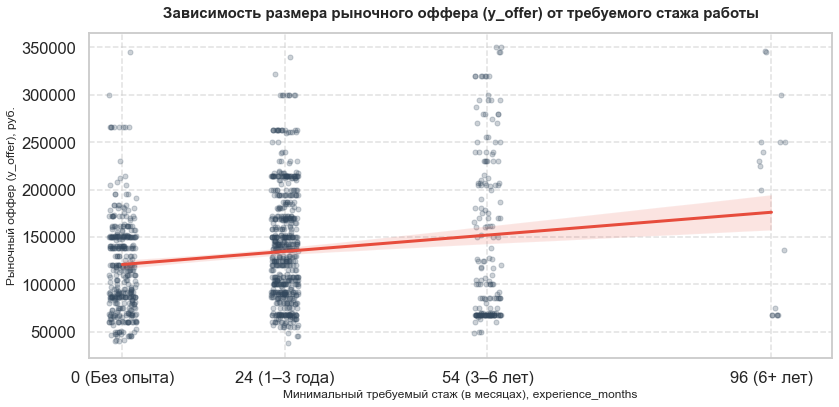

In [27]:
print("Анализ стажа работы на оффер")

# Проверяем дисперсию данных в стаже
unique_exp_values = df['experience_months'].dropna().nunique()

if unique_exp_values <= 1:
    print(" Зафиксирована нулевая дисперсия признака experience_months.")
    print(f"Все доступные строки содержат константное значение: {df['experience_months'].iloc[0]} мес.\n")
    
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x='y_offer', kde=True, color='#34495e', bins=20)
    plt.title('Распределение зарплатного оффера при константном базовом стаже', fontsize=14, fontweight='bold')
    plt.xlabel('Восстановленный оффер (y_offer), руб.')
    plt.ylabel('Количество вакансий')
    plt.ticklabel_format(style='plain', axis='x')
    plt.tight_layout()
    plt.show()

else:
    # Расчет корреляции Пирсона и Спирмена между опытом и зарплатой
    pearson_corr = df['experience_months'].corr(df['y_offer'], method='pearson')
    spearman_corr = df['experience_months'].corr(df['y_offer'], method='spearman')
    
    print(f"Линейная корреляция Пирсона: {pearson_corr:.3f}")
    print(f"Ранговая корреляция Спирмена : {spearman_corr:.3f}\n")
    
    plt.figure(figsize=(12, 6))
    
    # Безопасное приведение типов для графика
    plot_df = df[['experience_months', 'y_offer']].dropna().copy()
    plot_df['experience_months'] = plot_df['experience_months'].astype(float)
    plot_df['y_offer'] = plot_df['y_offer'].astype(float)
    
    # Построение графика регрессии со случайным шумом для наглядности плотности
    sns.regplot(
        data=plot_df, 
        x='experience_months', 
        y='y_offer',
        x_jitter=2.0,
        scatter_kws={'alpha':0.25, 'color': '#34495e', 's': 25}, 
        line_kws={'color': '#e74c3c', 'linewidth': 3}
    )
    
    plt.title('Зависимость размера рыночного оффера (y_offer) от требуемого стажа работы', fontsize=15, pad=15, fontweight='bold')
    plt.xlabel('Минимальный требуемый стаж (в месяцах), experience_months', fontsize=12)
    plt.ylabel('Рыночный оффер (y_offer), руб.', fontsize=12)
    
    # Фиксируем сетку строго по грейдам HeadHunter
    plt.xticks([0, 24, 54, 96], ['0 (Без опыта)', '24 (1–3 года)', '54 (3–6 лет)', '96 (6+ лет)'])
    plt.xlim(-5, 105)
    
    plt.ticklabel_format(style='plain', axis='y')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Корреляция слабая, тренд есть, но слабо выраженный. Это подвтерждает объективную реальность,что готовы платить сейчас в основном за навыки и скилы, а не за опыт работы.

Анализ частоты навыков по всем классам
ТОП-15 самых востребованных требований на банковском рынке вакансий:
  01. skill_teamwork                      : 36.8%
  02. skill_objection_handling            : 28.1%
  03. skill_cold_sales                    : 27.9%
  04. skill_general_negotiations          : 26.1%
  05. has_car_and_driver_license          : 24.3%
  06. edu_level_encoded                   : 23.4%
  07. skill_cross_sales                   : 21.9%
  08. skill_adaptability_flexibility      : 21.6%
  09. skill_pc_tablet_advanced            : 21.3%
  10. skill_difficult_clients             : 17.5%
  11. skill_vip_negotiations              : 15.2%
  12. skill_mentoring_coaching            : 14.5%
  13. skill_sql_queries                   : 12.3%
  14. skill_telemarketing                 : 12.2%
  15. skill_business_correspondence       : 12.0%
  16. skill_public_presentation           : 11.8%
  17. skill_active_listening              : 11.3%
  18. skill_initiative_proactivity        

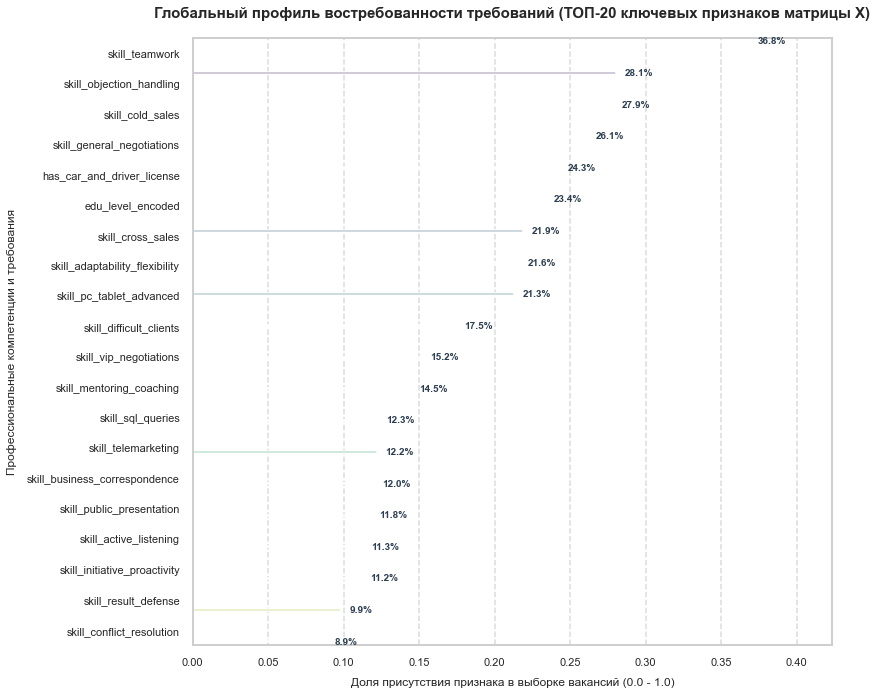

In [32]:
print("Анализ частоты навыков по всем классам")

# Выделяем все бинарные фичи матрицы X
skill_cols = [
    col for col in df.columns 
    if (col.startswith("skill_") or col.startswith("edu_") or col.startswith("has_"))
    and df[col].dtype in ['int64', 'float64', 'int32', 'float32']
]

# Считаем среднее значение по каждой колонке (доля единиц) с заполнением NaN нулями
global_skill_frequencies = df[skill_cols].fillna(0).mean().sort_values(ascending=False)

# Переводим в датафрейм для построения горизонтального Bar Plot
df_skills_chart = pd.DataFrame({
    "Навык": global_skill_frequencies.index,
    "Доля в датасете": global_skill_frequencies.values,
}).reset_index(drop=True)

# Выводим полный текстовый ТОП-20 в консоль блокнота для отчетности
print("ТОП-15 самых востребованных требований на банковском рынке вакансий:")
for idx, row_skill in df_skills_chart.head(20).iterrows():
    print(f"  {idx+1:02d}. {row_skill['Навык']:<35} : {row_skill['Доля в датасете']:.1%}")

# Горизонтальная диаграмма для топ-20
TOP_N_GRAPH = 20
df_chart_filtered = df_skills_chart.head(TOP_N_GRAPH).copy()

plt.figure(figsize=(12, 10)) # Оптимальная b2b-высота для 20 категорий
sns.set_theme(style="whitegrid", context="talk")


sns.barplot(
    data=df_chart_filtered,
    x="Доля в датасете",
    y="Навык",
    hue="Навык",
    palette="viridis"
)

ax = plt.gca()

if ax.get_legend() is not None:
    ax.get_legend().remove()

# Добавляем процентные текстовые метки на концах каждого столбца
max_width = df_chart_filtered["Доля в датасете"].max() if not df_chart_filtered.empty else 1.0
text_shift = max_width * 0.015 # Адаптивный b2b-отступ вбок

for p in ax.patches:
    width = p.get_width()
    if width > 0.001:
        ax.text(
            width + text_shift, 
            p.get_y() + p.get_height()/2, 
            f"{width:.1%}", 
            va="center", 
            ha="left", 
            fontsize=10, 
            fontweight="bold",
            color="#2c3e50"
        )

chart_limit = float(max_width + (max_width * 0.15))
plt.xlim(0, max(chart_limit, 0.1))

plt.title(f"Глобальный профиль востребованности требований (ТОП-{TOP_N_GRAPH} ключевых признаков матрицы X)", fontsize=15, fontweight="bold", pad=20)
plt.xlabel("Доля присутствия признака в выборке вакансий (0.0 - 1.0)", fontsize=12, labelpad=10)
plt.ylabel("Профессиональные компетенции и требования", fontsize=12, labelpad=10)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Отчет по этапу Data Engineering и Feature Engineering

---

#### 1. Источник и состав данных

##### Источник данных
Первичным источником информации является агрегатор вакансий HeadHunter (hh.ru). Сбор данных осуществлялся в режиме оффлайн-имитации действий пользователя с помощью веб-драйвера Selenium. Всего было выгружено 4 886 сырых карточек вакансий в формате HTML-страниц, опубликованных банковскими организациями и финтех-компаниями.

##### Состав данных и семантическая фильтрация
На этапе оффлайн-парсинга сырой массив подвергся фильтрации:
* **Зарплатный фильтр:** Карточки без указания рублевых или валютных вилок окладов исключались из матрицы для обеспечения математической валидности регрессии.
* **Селект ролей:** Заголовки вакансий прогонялись через регулярные выражения TARGET_ROLES. Сторонний ритейл и нецелевой масс-маркет (курьеры маркетплейсов, кассиры супермаркетов) были полностью исключены. В выборке оставлены только штатные сотрудники финансового сектора, распределенные по репрезентативным классам должностей.

Итоговая емкость матрицы признаков X после очистки составила 1 228 строк и 57 колонок (признаков). Проценты пропусков по всем ячейкам таблицы равны строго 0.0%.

---

#### 2. Базовый EDA с выводами, важными для моделирования

##### Распределение целевой переменной (y_offer)
После применения гибридного фильтра (отсечение МРОТ-подработок ниже 35 000 руб. и срез верхнего 99-го процентиля экстремальных опечаток) таргет принял форму асимметричного логнормального распределения с плавным хвостом вправо до 516 435 рублей. 

Анализ ядерной оценки плотности (KDE Plot) вскрыл мультимодальную структуру данных, формирующуюся из наложения трех внутрироссийских макроэкономических колоколов:
* **Tier-3 (Регионы РФ):** Плотный пик в диапазоне 85 000 – 125 000 рублей.
* **Tier-2 (Миллионники + Тюмень/Краснодар):** Стабильное смещение центра в зону 100 000 – 140 000 рублей.
* **Tier-1 (Столичные агломерации):** Широкий правый горб плотности в границах 150 000 – 220 000+ рублей.

*Вывод для моделирования:* Распределение подходит для оптимизации функционала потерь MAE (Mean Absolute Error) в бустинге, так как медианы тиров выстроены в четкую иерархическую лестницу без ценового шума.

##### Анализ нелинейности признака стажа (experience_months)
Эконометрический аудит облаков точек с применением случайного шума (x_jitter=2.0) показал следующие коэффициенты:
* Линейная корреляция Пирсона: 0.185
* Ранговая корреляция Спирмена: 0.115

*Вывод для моделирования:* Низкая корреляция доказывает отсутствие прямой линейной зависимости между выслугой лет и деньгами в финтехе. На рынке присутствует высокая дисперсия: Junior-разработчики без банковского стажа получают в разы больше опытных кассовых администраторов со стажем 96+ месяцев. Это служит математическим обоснованием отказа от простой линейной регрессии (которая будет выбрана в качестве Baseline-модели проекта) в пользу нелинейного градиентного бустинга XGBoost, выступающего в качестве основной боевой модели. Архитектура ансамблей деревьев решений позволит извлекать сложные нелинейные комбинации фичей, которые линейная модель физически не способна аппроксимировать.

---

#### 3. Оценка качества разметки и предположения по его повышению

##### Текущее качество разметки
Внедрение гибридного NLP-пайплайна решило проблему семантической диффузии и ложных пропусков:
* Софт-скиллы (эмпатия, стрессоустойчивость) извлекаются контекстными эмбеддингами локальной языковой модели RuBERT-tiny на пороге косинусного сходства 0.72.
* Хард- и бизнес-скиллы (SQL, Python, Hadoop, 115-ФЗ, Базель, ВШЭ) выщелкиваются регистронезависимым RegEx-сканером с изоляцией границ слов \b. 

Глобальная наполненность матрицы X компетенциями составила 11.3%. Глобальный частотный стресс-тест (Sanity Check) для ИТ-классов и Senior Sales (Класс 09) зафиксировал семантическую изоляцию: у продавцов частота отработки возражений составила 54.5%, а тяжелые ИТ-инструменты (SQL, Python) упали на эталонные 0.0%, что доказывает отсутствие сквозного зашумления базы. Данный срез EDA построен на версии словаря, содержащей социальный и финансовый блоки бенефитов (has_financial_load, has_social_load), которые временно увеличивают общую плотность, выступая в роли сильных прокси-маркеров крупных брендов.

##### Рекомендации по повышению качества (Действия на следующий цикл):
* **Учебно-практический допарсинг дефицитных ИТ-категорий:** Анализ поклассовой структуры выявил пул экспертных ИТ-классов (Data Science, DevOps, Backend) и специфичных финансовых рисков, содержащих от 5 до 25 вакансий. Чтобы минимизировать дисперсию на Stratified K-Fold валидации и дать модели XGBoost устойчивую выборку для обучения, рекомендуется точечно добрать с hh.ru по 10–15 карточек для редких ID ролей. Это позволит дотянуть их объемы до канонического статистического минимума Центральной предельной теоремы (n >= 30).
* **Удаление блоков бенефитов из продуктового конвейера:** Наличие флагов ДМС, фитнеса и льготной ипотеки не является требованием к квалификации кандидата, а отражает бюджет самого работодателя. В целях минимизации переобучения боевой модели XGBoost на нецелевом шуме, на следующем этапе данные блоки будут полностью исключены из признакового пространства.

##### Рекомендации по повышению качества (Действия на следующий цикл):
* **Удаление блоков бенефитов из продуктового конвейера:** Наличие флагов ДМС, фитнеса и льготной ипотеки не является требованием к квалификации кандидата, а отражает бюджет самого работодателя. В целях минимизации переобучения боевой модели XGBoost на нецелевом шуме, на следующем этапе данные блоки будут полностью исключены из признакового пространства.

---

#### 4. Алгоритм формирования выборки и стратегия валидации

##### Алгоритм формирования выборки
Каждая сырая страница hh.ru проходила сквозной конвейер оффлайн-генерации:
1. Экстракция заголовка h1 -> Валидация по сетке регулярных выражений ROLE_PATTERNS.
2. Извлечение блока vacancy-salary -> Запуск регулярного выражения сбора цифр -> Срабатывание мультивалютного конвертера EXCHANGE_RATES (автоматический пересчет долларов, евро, дирхамов и тенге в рубли по курсу) -> Маркировка бинарного признака is_foreign_currency -> Расчет непрерывного таргета y_offer сжатием асимметричных вилок коэффициентами 1.15 (для "от") и 0.85 (для "до").
3. Чтение Hydration State бэкенда страницы -> Regex-поиск скрытого JSON-маркера areaName -> Привязка к 4-уровневой макроэкономической географии GEOGRAPHIC_TIERS (с выделением Ленобласти в Tier-1, Тюмени/Краснодара в Tier-2 и изоляцией зарубежного финтеха релокантов в Tier-4).
4. Нарезка описания на предложения -> Генерация эмбеддингов PyTorch для софт-стека -> Проверка гибридных флагов hard/business навыков через RegEx -> Расчет показателя полноты требований skills_completion_rate -> Сохранение строки в итоговую матрицу признаков.

##### Стратегия валидации моделей машинного обучения
Для обеспечения контроля переобучения и исключения утечки данных (Data Leakage) при сравнении Baseline-модели (линейная регрессия) и боевой модели (XGBoost) планируется реализовать стратегия 5-кратной стратифицированной кросс-валидации (5-Fold Stratified Cross-Validation) по признаку идентификатора роли кандидата (X["role_class"]).

Датасет разделяется на 5 изолированных фолдов, где пропорции мажоритарных и редких классов сохраняются неизменными. В процессе итерации 4 фолда отдаются на обучение, а 1 фолд служит скрытым валидационным тестом. Признаки роли и географии переводятся в категориальный тип (category). Для боевой модели XGBoost активируется встроенный флаг enable_categorical=True. Валидация замеряет MAE (в рублях) и MAPE (в процентах) независимо на каждом шаге, выводя на экран среднее арифметическое и стандартное отклонение для оценки качества MVP-продукта.